In [2]:
# 全局设置
import datetime as dt
import warnings
warnings.filterwarnings(action='ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False# 正确显示负号
from IPython.display import HTML

from QuantStudio import __QS_MainPath__

# 策略回测

策略回测用于评估交易策略在历史数据上的表现。QuantStudio 的策略回测功能位于 `BackTest.Strategy` 子模块中，建立在回测基本框架之上。

> **前置阅读**：回测框架的整体架构、`BTNode`/`BTReport` 基类、执行流程（三层嵌套 `Cache → Context → Engine`）以及"算子-节点分离"设计模式，请先参阅 **[基本框架](基本框架.ipynb)**。计算图与引擎的基础知识请参阅 **[计算图框架](../Core/计算图框架.ipynb)** 和 **[计算引擎](../Core/计算引擎.ipynb)**。

## 模块概览

`QuantStudio.BackTest.Strategy` 提供以下核心组件：

| 组件 | 类型 | 功能 |
|------|------|------|
| `MakeAccount` | `PanelOperator` | 账户创建算子，基于交易信号撮合成交、更新持仓和现金 |
| `MakeStrategy` | `PanelOperator`（可继承） | 策略创建算子，通过重写 `genSignal` 方法实现自定义策略逻辑 |
| `AccountReport` | `BTNode` | 账户报告节点，计算净值、收益率、绩效统计并生成 HTML 报告 |
| `CalcPortfolioNV` | `PanelOperator` | 投资组合净值计算算子，基于权重因子和价格因子计算净值 |
| `CalcPortfolioReturn` | `PanelOperator` | 投资组合收益率计算算子 |

`genAccountOutput` 函数用于将账户时间序列数据处理为包含净值、收益率和各项绩效统计的标准输出字典。

## 策略回测的两种模式

QuantStudio 提供两种策略回测方式：

### 方式一：信号因子 + MakeAccount（快速模式）

适用于策略信号可以通过因子算子组合表达的场景。用户将策略逻辑表达为**信号因子**（目标权重或买卖数量），直接传给 `MakeAccount` 算子。不需要编写 Python 代码逻辑，完全通过因子算子的组合来实现策略。

**优点**：简洁、完全基于算子声明式构建、无需编程
**限制**：策略逻辑必须能用现有因子算子表达

### 方式二：继承 MakeStrategy（自定义模式）

适用于策略逻辑复杂、无法用现有算子组合表达的场景。用户继承 `MakeStrategy` 并重写 `genSignal` 方法，在每个再平衡时点自由编写 Python 代码来生成交易信号。

**优点**：完全灵活，可实现任意复杂的策略逻辑
**限制**：需要编写 Python 代码

## genAccountOutput — 账户输出数据处理

`genAccountOutput` 是一个工具函数，将账户的现金、负债、市值等时间序列处理为标准输出字典（包含净值、收益率、绩效统计等）。

```python
from QuantStudio.BackTest.Strategy.Strategy import genAccountOutput

def genAccountOutput(
    init_cash: float,                          # 初始资金
    cash_series: pd.Series,                    # 现金时间序列
    debt_series: pd.Series,                    # 负债时间序列
    account_value_series: pd.Series,           # 账户价值时间序列
    cash_record: pd.DataFrame,                 # 现金流记录
    debt_record: pd.DataFrame,                 # 负债记录
    risk_free_rate: float = 0.0                # 无风险利率
) -> dict
```

**内部处理逻辑**：
1. 从账户价值一阶差分计算收益，首期收益 = 首期账户价值 - 初始资金
2. 扣除现金流注入对收益的影响（现金流注入不视为策略收益）
3. 收益率 = 收益 / 前期账户价值的绝对值
4. 净值 = (1 + 收益率) 的累计乘积
5. 如有负债，额外计算无杠杆收益率（扣除杠杆对收益的影响）
6. 调用 `summaryStrategy` 生成年化收益率、波动率、Sharpe、最大回撤等绩效统计

`AccountReport` 在内部调用此函数处理 `MakeAccount`/`MakeStrategy` 产生的账户因子数据。

In [ ]:
# 参数设置
from QuantStudio.Factor.HDF5DB import HDF5DB
FDB = HDF5DB(args={"MainDir": Path(__QS_MainPath__).parent / "docs/data/HDF5"}).connect()

StartDT, EndDT = dt.datetime(2025, 1, 1), dt.datetime(2025, 3, 31)# 数据起止时间
TestStartDT, TestEndDT = dt.datetime(2025, 2, 1), EndDT# 测试起止时间

FT = FDB.getTable("stock_cn_day_bar")
DTRuler = FT.getDateTime(start_dt=StartDT, end_dt=EndDT)
TestDTs = FT.getDateTime(start_dt=TestStartDT, end_dt=TestEndDT)
SectionIDs = IDs = FT.getID()

# 再平衡时点序列
from QuantStudio.Tools.DateTimeFun import getMonthLastDateTime
BalanceDTs = getMonthLastDateTime(DTRuler)# 月末

## 方式一：信号因子 + MakeAccount（快速模式）

下面展示使用信号因子 + `MakeAccount` 构建等权配置 EP TTM 前 20% 股票的策略。策略信号完全通过因子算子组合来表达：`SectionRank` 排序 + `>= 0.8` 阈值筛选 + 归一化权重。

2026-06-27 11:20:03,551 | QS | WARNING : 找不到配置文件: C:\Users\hst\QuantStudioConfig\FeatherFactorCacheConfig.json
2026-06-27 11:20:03,555 | QS | INFO : 开始初始化计算...
2026-06-27 11:20:03,559 | QS | INFO : 初始化计算完成, 耗时 0.003282100020442158 秒
2026-06-27 11:20:03,559 | QS | INFO : 开始准备计算...
  0% (0 of 4) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (4 of 4) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
2026-06-27 11:20:03,561 | QS | INFO : 准备计算完成, 耗时 0.0021280999935697764 秒
2026-06-27 11:20:03,562 | QS | INFO : 开始正式计算...
2026-06-27 11:20:03,995 | QS | INFO : 正式计算完成, 耗时 0.4332373999932315 秒


,绝对表现,基准表现,相对表现
起始时点,2025-02-01,2025-02-01,2025-02-01
结束时点,2025-03-31,2025-03-31,2025-03-31
时点数,59,59,59
总收益率,nan%,8.87%,nan%
年化收益率,nan%,70.71%,nan%
年化波动率,0.00%,4230.95%,0.00%
Sharpe比率,nan,0.02,nan
收益风险比,nan,0.02,nan
胜率,nan%,49.15%,nan%
最大回撤率,0.00%,98.33%,0.00%

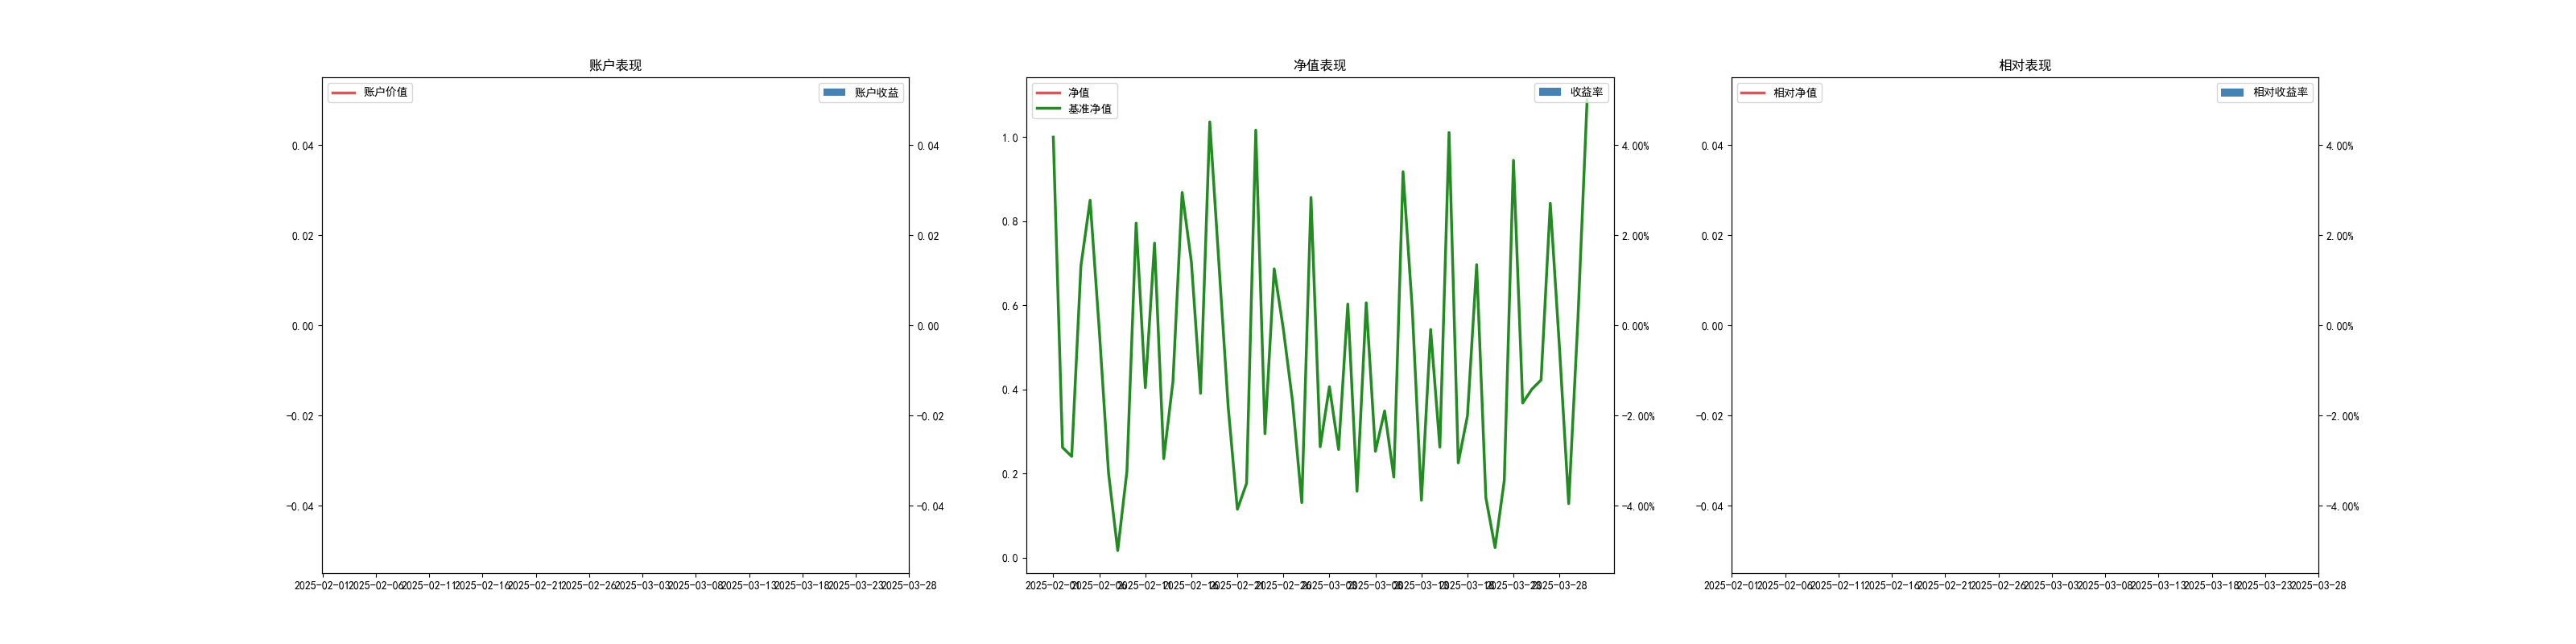

In [ ]:
# 策略测试
from QuantStudio.Core.CalcEngine import Engine
from QuantStudio.Core.Node import DTLocalContext, DTInitData
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Factor.BasicOperator import rename
import QuantStudio.Factor.FactorOperator as fo
from QuantStudio.Factor.FactorCache import FeatherFactorCache
from QuantStudio.BackTest.BackTestModel import BTReport
from QuantStudio.BackTest.Strategy.Strategy import MakeAccount, AccountReport

FT = FDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = FDB.getTable("stock_cn_status")
IfListed = FT.getFactor("if_listed")

FT = FDB.getTable("stock_cn_factor_value")
EP = FT.getFactor("ep_ttm")

Mask = (IfListed == 1)

# 策略信号: EP TTM 属于前 20% 的股票等权配置
StrategySignal = fo.SectionRank(ascending=True, uniformization=True)(EP, mask=Mask, factor_args={"CalcDTRuler": BalanceDTs}) >= 0.8
StrategySignal = rename(StrategySignal / fo.Aggregate(aggr_func=np.nansum)(StrategySignal), factor_name="Signal")# 归一化

# 账户因子
Account = MakeAccount(signal_type="目标权重", init_cash=1e6, start_dt=TestDTs[0])(last_price=Price, signal=StrategySignal)

# 基准因子
FT = FDB.getTable("index_cn_day_bar")
BmkNV = FT.getFactor("close", args={"SectionIDs": ["000905.SH"]})

# 策略报告
StrategyReport = AccountReport(account=Account, bmk_nv=BmkNV, args={"GenReport": True})

NodeList = [StrategyReport]
Report = BTReport(bt_node_list=NodeList)

with FeatherFactorCache(args={"DTRuler": DTRuler, "CacheDir": "../data/Cache", "StartMode": "new"}) as Cache:
    with FactorContext(DTRuler=DTRuler, SectionIDs=SectionIDs, DataCache=Cache) as Context:
        with Engine() as ExecEngine:
            Rslt = ExecEngine.run([Report], Context, fwd_data_list=[DTLocalContext(DTs=TestDTs)], init_data_list=[DTInitData(DTRange=(TestDTs[0], TestDTs[-1]))])

display(HTML(Rslt[0]["Report"]))

## 方式二：继承 MakeStrategy（自定义模式）

下面展示通过继承 `MakeStrategy` 并重写 `genSignal` 方法实现自定义策略——每期买入 EP TTM 最大的那只股票。这种方式适用于策略逻辑无法用现有因子算子表达的场景。

2026-06-27 11:21:41,547 | QS | WARNING : 找不到配置文件: C:\Users\hst\QuantStudioConfig\FeatherFactorCacheConfig.json
2026-06-27 11:21:41,551 | QS | INFO : 开始初始化计算...
2026-06-27 11:21:41,554 | QS | INFO : 初始化计算完成, 耗时 0.0015485000039916486 秒
2026-06-27 11:21:41,554 | QS | INFO : 开始准备计算...
  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (3 of 3) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
2026-06-27 11:21:41,557 | QS | INFO : 准备计算完成, 耗时 0.0019398999866098166 秒
2026-06-27 11:21:41,557 | QS | INFO : 开始正式计算...
2026-06-27 11:21:41,860 | QS | INFO : 正式计算完成, 耗时 0.3023596999992151 秒


,绝对表现,基准表现,相对表现
起始时点,2025-02-01,2025-02-01,2025-02-01
结束时点,2025-03-31,2025-03-31,2025-03-31
时点数,59,59,59
总收益率,nan%,8.87%,nan%
年化收益率,nan%,70.71%,nan%
年化波动率,0.00%,4230.95%,0.00%
Sharpe比率,nan,0.02,nan
收益风险比,nan,0.02,nan
胜率,nan%,49.15%,nan%
最大回撤率,0.00%,98.33%,0.00%

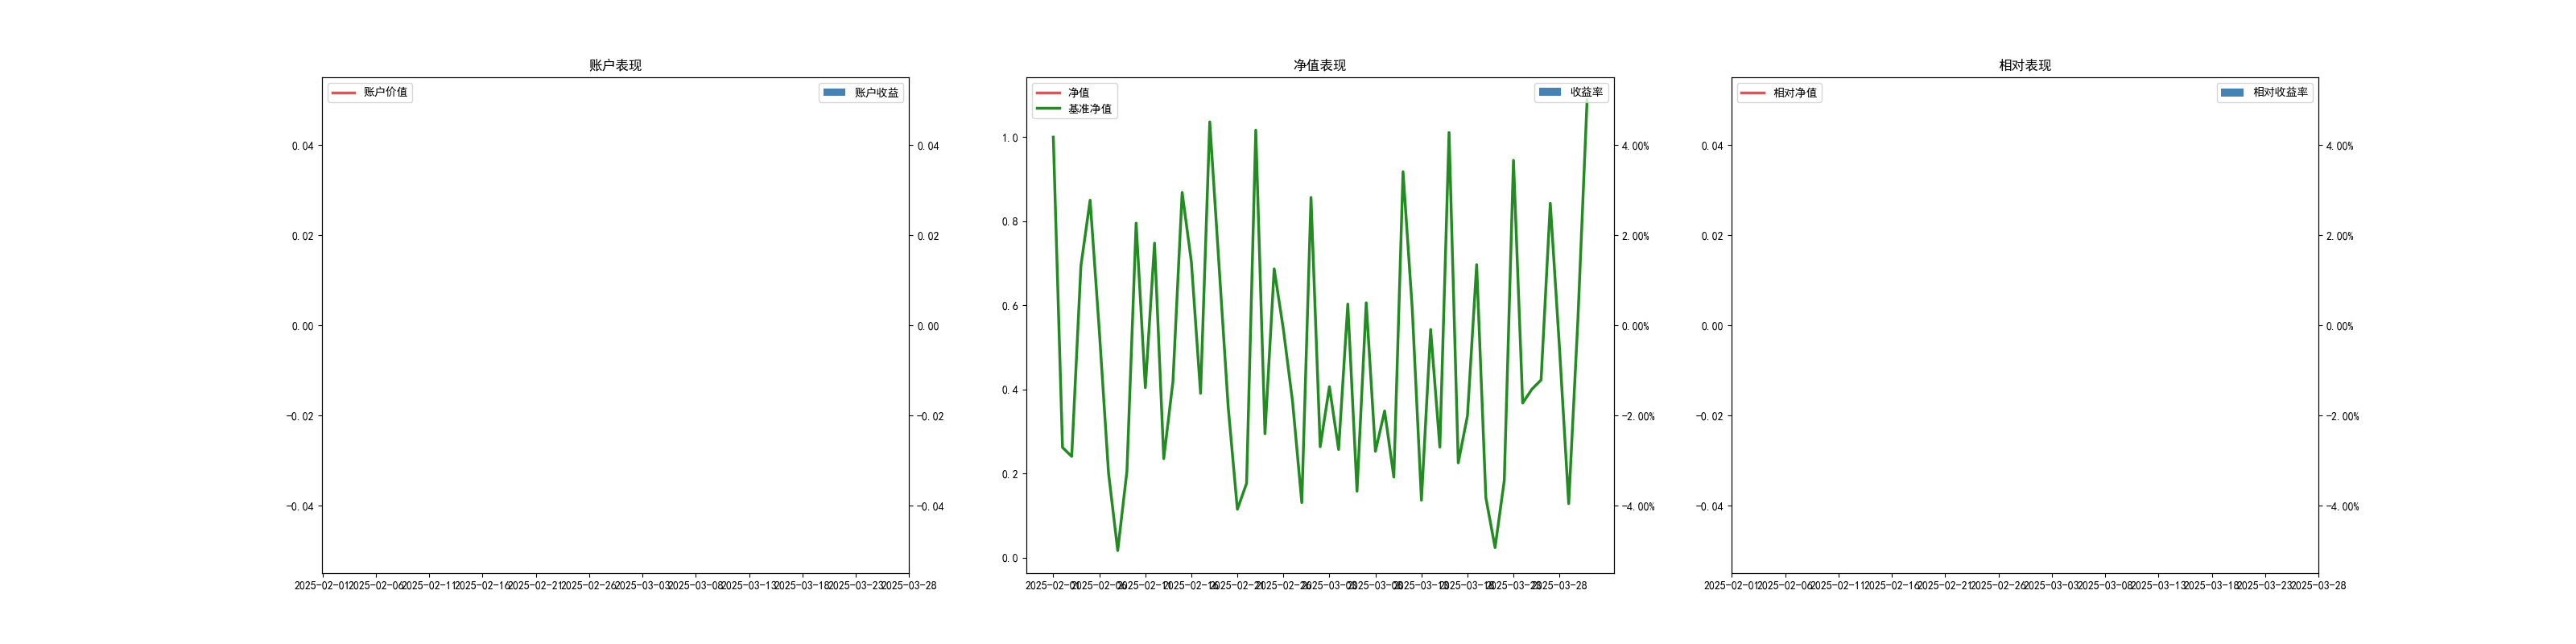

In [ ]:
# 策略测试
from QuantStudio.Core.CalcEngine import Engine
from QuantStudio.Core.Node import DTLocalContext, DTInitData
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Factor.BasicOperator import rename
import QuantStudio.Factor.FactorOperator as fo
from QuantStudio.Factor.FactorCache import FeatherFactorCache
from QuantStudio.BackTest.BackTestModel import BTReport
from QuantStudio.BackTest.Strategy.Strategy import MakeStrategy, AccountReport

class MakeMyStrategy(MakeStrategy):
    def genSignal(self, f, idt, x, last_price, cash, position_num, args):
        """买入 EP 最大的那只股票"""
        iID = x[0].iloc[0].idxmax()
        return pd.Series(1, index=[iID])

FT = FDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = FDB.getTable("stock_cn_status")
IfListed = FT.getFactor("if_listed")

FT = FDB.getTable("stock_cn_factor_value")
EP = FT.getFactor("ep_ttm")

# 策略因子
Strategy = MakeMyStrategy(signal_type="目标权重", init_cash=1e6, start_dt=TestDTs[0], x_lookback=[0], x_section_ids=[None])(EP, last_price=Price)

# 基准因子
FT = FDB.getTable("index_cn_day_bar")
BmkNV = FT.getFactor("close", args={"SectionIDs": ["000905.SH"]})

# 策略报告
StrategyReport = AccountReport(account=Strategy, bmk_nv=BmkNV, args={"GenReport": True})

NodeList = [StrategyReport]
Report = BTReport(bt_node_list=NodeList)

CacheDir = Path(__QS_MainPath__).parent / "docs/data/Cache"
if not CacheDir.exists(): CacheDir.mkdir(parents=True)

with FeatherFactorCache(args={"DTRuler": DTRuler, "CacheDir": CacheDir, "StartMode": "new"}) as Cache:
    with FactorContext(DTRuler=DTRuler, SectionIDs=SectionIDs, DataCache=Cache) as Context:
        with Engine() as ExecEngine:
            Rslt = ExecEngine.run([Report], Context, fwd_data_list=[DTLocalContext(DTs=TestDTs)], init_data_list=[DTInitData(DTRange=(TestDTs[0], TestDTs[-1]))])

display(HTML(Rslt[0]["Report"]))

## CalcPortfolioNV — 投资组合净值计算算子

`CalcPortfolioNV` 是一个 `PanelOperator`，基于投资组合权重因子和价格因子，通过向量化回测计算各组净值序列。常用于分位数组合回测或多策略对比场景。

### 构造参数

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `descriptor_ids` | `List[str]` | — | 依赖因子的截面 ID 序列 |
| `start_dt` | `Optional[datetime]` | `None` | 净值开始日，None 表示从计算的第一个时点开始 |
| `calc_type` | `Literal["numpy", "pandas"]` | `"numpy"` | 计算方式，numpy 向量化更快 |

### `__call__` 参数

| 参数 | 类型 | 说明 |
|------|------|------|
| `*portfolio` | `Factor` | 待计算净值的投资组合权重因子（至少 1 个），每个时点的因子值为各证券的资金权重 |
| `price` | `Factor` | 证券价格/净值因子 |
| `init_nv` | `float \| Factor` | 初始净值，默认 1 |
| `fee_rate` | `float \| Factor` | 交易费率，默认 0 |
| `portfolio_name_list` | `Optional[List[str]]` | 组合名称列表，None 时自动生成（取因子名或 `P0, P1, ...`） |
| `factor_args` | `dict` | 传递给净值因子的参数 |

**返回值**：净值因子，列为各组合的净值序列。

> **注意**：`portfolio_name_list` 会自动按升序排列组合；若有重复名称，系统会使用 `P0, P1, ...` 替代。

### 构造示例

```python
from QuantStudio.BackTest.Strategy.AllocationStrategy import CalcPortfolioNV

calcPortfolioNV = CalcPortfolioNV(descriptor_ids=SectionIDs, start_dt=TestDTs[0])
PortfolioNV = calcPortfolioNV(
    *QuantilePortfolios,   # 多个权重因子
    price=Price,
    init_nv=1
)
```

## 输出解读

`AccountReport` 生成的 HTML 报告按以下顺序展示：

### 报告内容

1. **参数设置** — 显示回测参数：无风险利率、再平衡时点等
2. **账户表现图** — 账户价值曲线（折线）+ 收益柱状图（双轴）
3. **净值表现图** — 净值曲线 + 收益率柱状图 + 基准净值对比（如有）
4. **考虑资金投入的表现**（如有现金流注入）
5. **相对表现图**（如有基准）— 相对净值曲线 + 相对收益率柱状图
6. **绩效统计表** — 包含绝对表现和相对表现的所有指标

### 输出字典结构

`AccountReport` 的 `backward_compute` 返回字典可通过编程方式访问各维度数据：

```python
# 访问账户报告输出
account_output = Output["0-账户报告"]

# 时间序列数据
ts = account_output["时间序列"]
nv = ts["净值"]               # 策略净值序列
returns = ts["收益率"]         # 日收益率序列
account_value = ts["账户价值"] # 账户总价值序列

# 绩效统计数据
stats = account_output["统计数据"]
annual_return = stats.loc["年化收益率"]    # 年化收益率
sharpe = stats.loc["Sharpe比率"]           # Sharpe 比率
max_dd = stats.loc["最大回撤"]             # 最大回撤
win_rate = stats.loc["胜率"]               # 胜率

# 相对表现（如有基准）
if "相对表现" in stats.columns:
    excess_return = stats["相对表现"].loc["年化收益率"]
    ir = stats["相对表现"].loc["信息比率"]
```

## 策略回测完整流程总结

```
                    因子算子组合                    重写 genSignal
                         │                              │
                         ▼                              ▼
                  信号因子 (Factor)              MakeMyStrategy
                         │                              │
                         └──────────┬───────────────────┘
                                    │
                                    ▼
                            MakeAccount.__call__
                           （撮合成交、更新持仓）
                                    │
                                    ▼
                            账户因子 (Factor)
                           [Cash, Position, Amount, Signal, TradeNum, TradePrice, Fee]
                                    │
                                    ▼
                            AccountReport
                           （净值计算、绩效统计、报告生成）
                                    │
                                    ▼
                              HTML 报告 + 统计数据
```

构造和执行两个阶段的详细说明请参阅 **[基本框架](基本框架.ipynb)**。

## AccountReport — 账户报告节点

`AccountReport` 是 `BTNode` 子类，接收账户因子（由 `MakeAccount` 或 `MakeStrategy` 产生），计算净值、收益率和绩效统计指标，并生成 HTML 报告。

### 参数

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `Name` | `str` | `"账户报告"` | 节点名称（冻结） |
| `RiskFreeRate` | `float` | `0` | 无风险利率，用于计算 Sharpe 比率（冻结） |
| `RebalanceDTs` | `Optional[List[datetime]]` | `None` | 再平衡时点，用于计算换手率（冻结） |
| `GenReport` | `bool` | `False` | 是否自动生成报告 |

### 构造方法

```python
AccountReport(
    account: Factor,                # 账户因子（由 MakeAccount 或 MakeStrategy 产生）
    bmk_nv: Optional[Factor]=None,  # 基准净值因子，用于计算相对表现指标
    args={}, config_file=None, **kwargs
)
```

### 输出数据结构

`backward_compute` 返回的字典包含以下键：

| 键 | 类型 | 说明 |
|------|------|------|
| `"时间序列"` | `DataFrame` | 包含现金、负债、证券市值、账户价值、收益、收益率、累计收益率、净值等列 |
| `"统计数据"` | `DataFrame` | 汇总绩效指标 |
| `"现金流记录"` | `DataFrame` | 每笔现金流明细 |
| `"负债记录"` | `DataFrame` | 每笔融资明细 |

**时间序列列说明**：

| 列 | 说明 |
|------|------|
| `现金` | 账户剩余现金 |
| `证券` | 持仓证券市值 |
| `账户价值` | 现金 + 证券 - 负债 |
| `收益` | 账户价值变动（扣除现金流注入） |
| `收益率` | 收益 / 前期账户价值的绝对值 |
| `净值` | (1 + 收益率) 的累计乘积 |
| `考虑资金投入的累计收益率` | （如有现金流注入）账户价值 / 累计资金投入 - 1 |
| `无杠杆收益率` | （如有负债）扣除杠杆后的收益率 |

**统计数据指标**：

| 指标 | 说明 |
|------|------|
| 年化收益率 | 累计收益率的年化值 |
| 年化波动率 | 收益率标准差的年化值 |
| Sharpe 比率 | 年化超额收益 / 年化波动率 |
| 最大回撤 | 净值曲线上的最大回撤幅度 |
| Calmar 比率 | 年化收益率 / 最大回撤 |
| 胜率 | 收益率为正的交易日占比 |
| 盈亏比 | 正收益均值 / 负收益均值（取绝对值） |

若提供了基准净值 `bmk_nv`，额外包含**相对表现**统计：
- 年化超额收益率
- 跟踪误差
- 信息比率
- 超额收益胜率

### 报告可视化

`AccountReport.genReport` 生成的 HTML 包含以下图表：
- **账户价值**曲线 + 收益柱状图
- **净值曲线**（含基准净值对比）
- **考虑资金投入的表现**（如有现金流）
- **相对净值**和**相对收益率**（如有基准）

## MakeStrategy — 策略创建算子（可继承）

`MakeStrategy` 继承自 `MakeAccount`，允许用户通过重写 `genSignal` 方法实现自定义策略逻辑。当策略信号无法用现有因子算子表达时，继承此类是最灵活的方式。

### 构造参数

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `signal_type` | `Literal["买卖数量", "目标权重"]` | `"目标权重"` | 信号类型，含义同 `MakeAccount` |
| `init_cash` | `float` | `1e6` | 初始资金 |
| `short_allowed` | `bool` | `False` | 是否允许卖空 |
| `start_dt` | `Optional[datetime]` | `None` | 净值开始日，None 表示从计算的第一个时点开始 |
| `x_lookback` | `List[int]` | `[]` | 策略所依赖因子的回溯期数列表 |
| `x_section_ids` | `List[Optional[List[str]]]` | `[]` | 策略所依赖因子的截面 ID 序列列表 |
| `signal_dts` | `Optional[List[datetime]]` | `None` | 信号生成时点，None 表示每个时点都生成信号 |

> **注意**：`x_lookback` 和 `x_section_ids` 长度必须相等，且与 `__call__` 中传入的 `*x` 因子个数相同。

### `genSignal` — 策略信号生成方法（必须重写）

```python
def genSignal(
    self,
    f: PanelOperation,                  # 策略因子对象
    idt: dt.datetime,                   # 当前时点
    x: List[pd.DataFrame],              # 策略依赖的因子数据，每个元素为 DataFrame(index=[datetime], columns=[证券ID])
    last_price: pd.Series,              # 当前证券最新价，Series(index=[证券ID])
    cash: float,                        # 当前账户剩余现金
    position_num: pd.Series,            # 当前账户持仓数量，Series(index=[证券ID])
    args: dict                          # 额外参数字典
) -> None | pd.Series:
```

**返回值**：
- `None` — 当前时点不产生交易信号
- `pd.Series` — 交易信号，index 为证券 ID。含义取决于 `signal_type`：
  - `"买卖数量"`：正值为买入股数，负值为卖出股数
  - `"目标权重"`：目标持仓权重（算子内部会转换为买卖数量）

### `__call__` 参数

| 参数 | 类型 | 说明 |
|------|------|------|
| `*x` | `Factor` | 策略依赖的因子列表，按顺序对应 `x_lookback` 和 `x_section_ids` |
| `last_price` | `Factor` | 最新价因子 |
| `init_account` | `Optional[Factor]` | 初始账户因子，None 时自动创建 |
| `buy_price` / `buy_limit` / `buy_fee` / `buy_amt_limit` | — | 交易限制参数，同 `MakeAccount.__call__` |
| `sell_price` / `sell_limit` / `sell_fee` / `sell_amt_limit` | — | 交易限制参数，同 `MakeAccount.__call__` |
| `extra_deps` | `List[Node]` | 额外依赖的计算节点 |
| `extra_section_ids` | `List[Optional[List[str]]]` | 额外依赖节点的截面 ID |
| `extra_lookback` | `List[int]` | 额外依赖节点的回溯期数 |
| `factor_args` | `dict` | 传递给策略因子的参数 |

### 构造示例

```python
from QuantStudio.BackTest.Strategy.Strategy import MakeStrategy

class MakeMyStrategy(MakeStrategy):
    def genSignal(self, f, idt, x, last_price, cash, position_num, args):
        """买入 EP 最大的那只股票"""
        iID = x[0].iloc[0].idxmax()
        return pd.Series(1, index=[iID])

# 创建策略因子
Strategy = MakeMyStrategy(
    signal_type="目标权重",
    init_cash=1e6,
    start_dt=TestDTs[0],
    x_lookback=[0],
    x_section_ids=[None]
)(EP, last_price=Price)
```

## MakeAccount — 账户创建算子

`MakeAccount` 是一个 `PanelOperator`（面板算子），在每个时点根据交易信号撮合成交，更新账户的现金和持仓。

### 构造参数

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `signal_type` | `Literal["买卖数量", "目标权重"]` | `"目标权重"` | 信号类型：买卖数量（直接指定股数）或目标权重（指定目标仓位比例） |
| `init_cash` | `float` | `1e6` | 初始资金 |
| `short_allowed` | `bool` | `False` | 是否允许卖空 |
| `start_dt` | `Optional[datetime]` | `None` | 净值开始日，None 表示从计算的第一个时点开始 |

### `__call__` 参数

| 参数 | 类型 | 说明 |
|------|------|------|
| `last_price` | `Factor` | 最新价因子，用于计算持仓市值和成交金额 |
| `signal` | `Factor` | 信号因子，含义取决于 `signal_type`：目标权重（截面和为 1 的权重）或买卖数量（正数为买入股数，负数为卖出股数） |
| `target_price` | `Optional[Factor]` | 目标价因子，None 表示信号转换为市价单 |
| `init_account` | `Optional[Factor]` | 初始账户因子（复合因子），None 时使用 `init_cash` 自动创建 |
| `buy_price` | `Optional[Factor]` | 买入成交价因子，None 时使用 `last_price` |
| `buy_limit` | `Optional[Factor]` | 禁止买入条件因子，值为 1 的 ID 禁止买入 |
| `buy_fee` | `float \| Factor` | 买入交易费率，默认 0 |
| `buy_amt_limit` | `Optional[Factor]` | 买入成交额限制因子，该期买入额不能超过该因子值 |
| `sell_price` | `Optional[Factor]` | 卖出成交价因子，None 时使用 `last_price` |
| `sell_limit` | `Optional[Factor]` | 禁止卖出条件因子，值为 1 的 ID 禁止卖出 |
| `sell_fee` | `float \| Factor` | 卖出交易费率，默认 0 |
| `sell_amt_limit` | `Optional[Factor]` | 卖出成交额限制因子，该期卖出额不能超过该因子值 |
| `factor_args` | `dict` | 传递给账户因子的参数（如 `CalcDTRuler` 指定计算时点） |

**返回值**：产生一个复合类型因子，每行包含 7 个子字段：

| 子字段 | 类型 | 说明 |
|--------|------|------|
| `Cash` | `double` | 剩余现金 |
| `Position` | `double` | 持仓数量 |
| `Amount` | `double` | 持仓金额 |
| `Signal` | `double` | 交易信号（原始输入） |
| `TradeNum` | `double` | 交易数量，正值表示买入，负值表示卖出 |
| `TradePrice` | `double` | 平均成交价 |
| `Fee` | `double` | 交易费用 |

### 撮合逻辑

账户算子在每个时点执行以下撮合流程：

1. **信号转换**：若 `signal_type="目标权重"`，将目标权重转换为买卖数量（基于当前账户市值和最新价）
2. **交易限制过滤**：检查买入/卖出禁止条件、成交额限制、卖空限制
3. **先卖后买**：先执行卖出交易释放现金，再执行买入交易（受可用现金约束）
4. **未成交撤单**：超出交易限制的市价单自动撤销
5. **小额清零**：持仓数量 < `1e-8` 或现金 < `1e-8` 的尾差自动清零

### 构造示例

```python
from QuantStudio.BackTest.Strategy.Strategy import MakeAccount

# 信号因子 + MakeAccount 创建账户
Account = MakeAccount(
    signal_type="目标权重",
    init_cash=1e6,
    start_dt=TestDTs[0]
)(
    last_price=Price,
    signal=StrategySignal
)
```